In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [2]:
df = pd.read_csv("/content/breast-cancer.csv")

In [3]:
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [4]:
df.isnull().sum()

,0
id,0
diagnosis,0
radius_mean,0
texture_mean,0
perimeter_mean,0
area_mean,0
smoothness_mean,0
compactness_mean,0
concavity_mean,0
concave points_mean,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [6]:
df['diagnosis'] = df['diagnosis'].map({'M': '1', 'B': '2'})

In [7]:
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [8]:
X = df.drop(['diagnosis', 'id'], axis=1)

X = X.apply(pd.to_numeric, errors='coerce')
X.fillna(X.mean(), inplace=True)
y = df['diagnosis']

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.30,random_state=42)

In [10]:
cart = DecisionTreeClassifier(criterion="gini",random_state=42)

cart.fit(X_train, y_train)

cart_pred = cart.predict(X_test)

print("Accuracy:", accuracy_score(y_test, cart_pred))
print(confusion_matrix(y_test, cart_pred))
print(classification_report(y_test, cart_pred))

Accuracy: 0.9415204678362573
[[ 60   3]
 [  7 101]]
              precision    recall  f1-score   support

           1       0.90      0.95      0.92        63
           2       0.97      0.94      0.95       108

    accuracy                           0.94       171
   macro avg       0.93      0.94      0.94       171
weighted avg       0.94      0.94      0.94       171



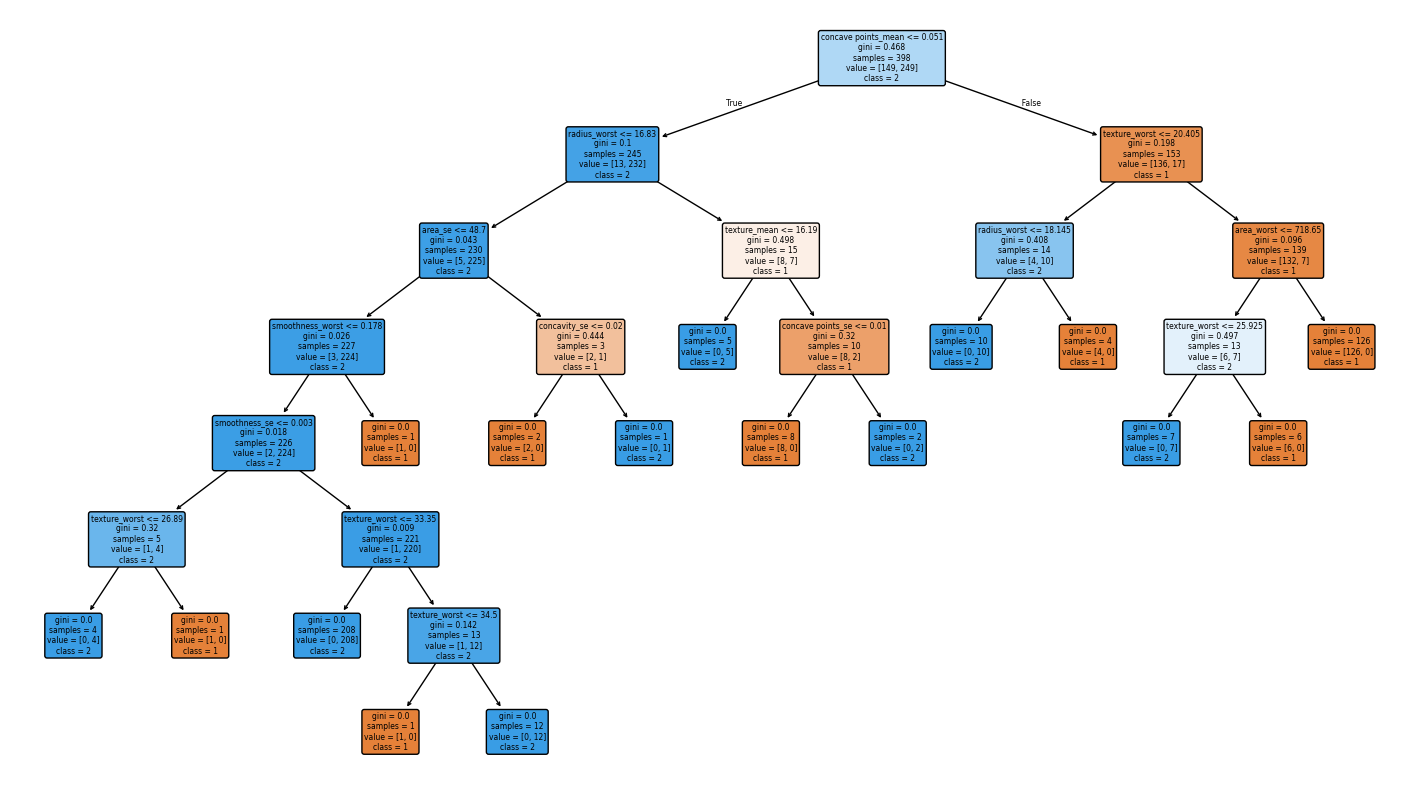

In [11]:
plt.figure(figsize=(18,10))

plot_tree(cart,feature_names=X.columns,class_names=y.unique().tolist(),filled=True,rounded=True)

plt.show()

In [12]:
id3 = DecisionTreeClassifier(criterion="entropy",random_state=42)

id3.fit(X_train, y_train)

id3_pred = id3.predict(X_test)

print("Accuracy:", accuracy_score(y_test, id3_pred))
print(confusion_matrix(y_test, id3_pred))
print(classification_report(y_test, id3_pred))

Accuracy: 0.9649122807017544
[[ 59   4]
 [  2 106]]
              precision    recall  f1-score   support

           1       0.97      0.94      0.95        63
           2       0.96      0.98      0.97       108

    accuracy                           0.96       171
   macro avg       0.97      0.96      0.96       171
weighted avg       0.96      0.96      0.96       171



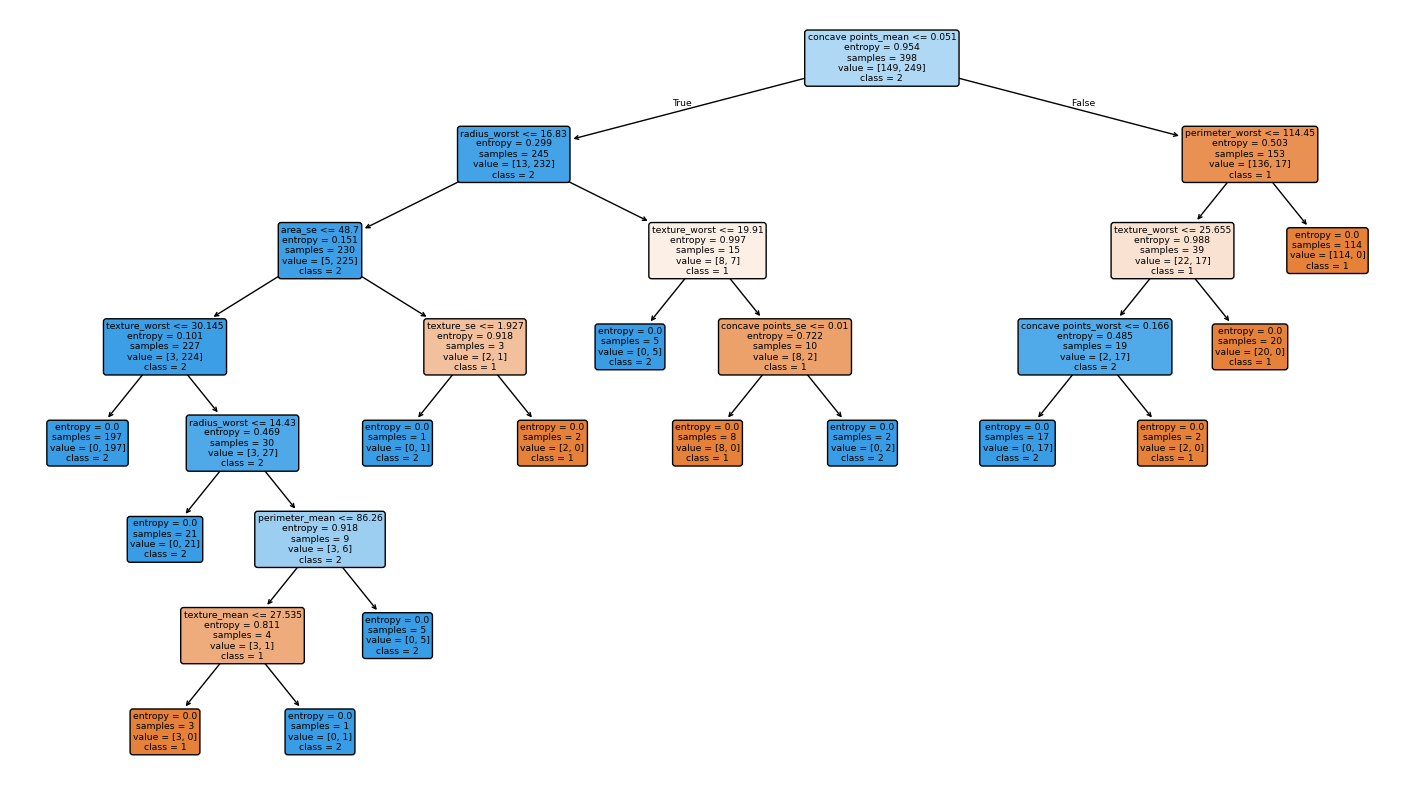

In [13]:
plt.figure(figsize=(18,10))

plot_tree(id3,feature_names=X.columns,class_names=y.unique().tolist(),filled=True,rounded=True)

plt.show()

In [14]:
!pip install chefboost
from chefboost import Chefboost as chef

chef_df = X.copy()

chef_df["Decision"] = y.map({'1': "Malignant", '2': "Benign"})

In [15]:
config = {"algorithm": "C4.5"}

model = chef.fit(chef_df, config=config)

26-06-29 16:05:37 - C4.5 tree is going to be built...
26-06-29 16:05:53 - -------------------------
26-06-29 16:05:53 - finished in 15.645742177963257 seconds
26-06-29 16:05:53 - -------------------------
26-06-29 16:05:53 - Evaluate train set
26-06-29 16:05:53 - -------------------------
26-06-29 16:05:53 - Accuracy: 96.13356766256591% on 569 instances
26-06-29 16:05:53 - Labels: ['Malignant' 'Benign']
26-06-29 16:05:53 - Confusion matrix: [[195, 5], [17, 352]]
26-06-29 16:05:53 - Precision: 97.5%, Recall: 91.9811%, F1: 94.6602%


In [19]:
sample_series = X.iloc[0]
sample = [float(x) for x in sample_series]

prediction = chef.predict(model, sample)

print("Prediction:", prediction)

Prediction: Malignant


In [20]:
importance = pd.DataFrame({"Feature": X.columns,"Importance": cart.feature_importances_})

importance = importance.sort_values(by="Importance",ascending=False)

print(importance)

                    Feature  Importance
7       concave points_mean    0.705839
21            texture_worst    0.114062
20             radius_worst    0.070187
23               area_worst    0.036653
1              texture_mean    0.022885
17        concave points_se    0.017164
13                  area_se    0.013563
24         smoothness_worst    0.010492
16             concavity_se    0.007152
14            smoothness_se    0.002004
5          compactness_mean    0.000000
3                 area_mean    0.000000
2            perimeter_mean    0.000000
0               radius_mean    0.000000
12             perimeter_se    0.000000
11               texture_se    0.000000
10                radius_se    0.000000
9    fractal_dimension_mean    0.000000
6            concavity_mean    0.000000
8             symmetry_mean    0.000000
4           smoothness_mean    0.000000
15           compactness_se    0.000000
18              symmetry_se    0.000000
19     fractal_dimension_se    0.000000


In [21]:
results = pd.DataFrame({"Algorithm": ["CART", "ID3"],"Accuracy": [accuracy_score(y_test, cart_pred),accuracy_score(y_test, id3_pred)]})

print(results)

  Algorithm  Accuracy
0      CART  0.941520
1       ID3  0.964912
